# Fixpunktiterationen
Die Abbildung

$$
    \vec{F}:[0,1]^2 \to [0,1]^2, \qquad \vec{F}(x, y) = \frac{1}{4} \cdot \begin{pmatrix} 
        \cos(x)+2 y \\
        x \cdot y^2 + \sin(x) + 1
    \end{pmatrix}
$$

ist eine Kontraktion auf $[0,1]^2$. 

Dies bedeutet zwei Dinge, **erstens** muss $\vec{F}(x, y)$ wieder innerhalb des Einheitsquadrats liegen und **zweitens** muss die Kontraktionseigenschaft erfüllt sein. 


Die Jacobimatrix von $\vec{F}$ ist
$$
    \vec{Df} = \frac{1}{4} \begin{pmatrix} 
        -\sin(x) & 2 \\
        y^2 + \cos(x) & 2 x y 
    \end{pmatrix}
$$

Folglich besitzt $\vec{F}$ genau einen Fixpunkt und die Iterationsfolge $\vec{x}_{k+1} = \vec{F}(\vec{x}_k)$ konvergiert gegen diesen Fixpunkt. Die Fipunktiteration zeigt, dass 

$$
\vec{x}_* \approx (0.53474221, 0.39865041)
$$




(-0.05, 1.05, -0.05, 1.05)

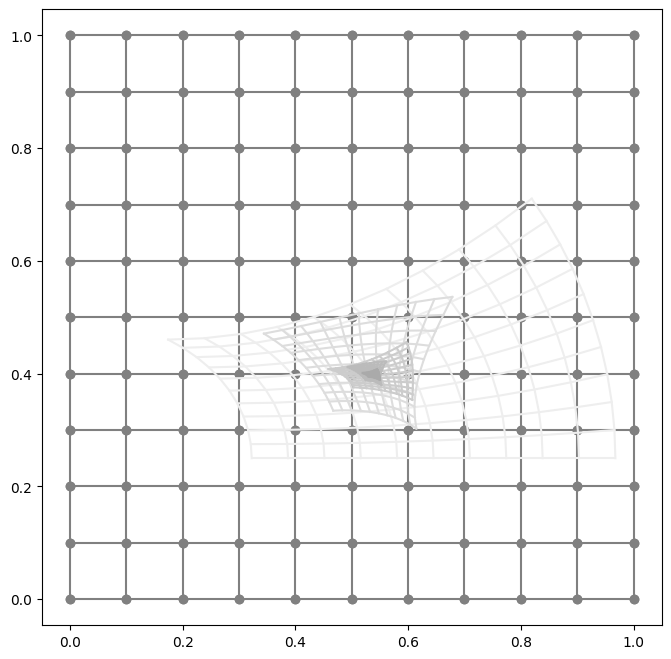

In [24]:
# -*- coding: utf-8 -*-
"""
Created on Sun Mar 27 19:10:04 2022

Beispiel für Fixpunktiteration und Newtonverfahren für ein 2x2 System
"""

import numpy as np
from matplotlib import pyplot as plt
import time


#%% Funktion für Fixpunktiteration
# "+ .0 * np.ones_like(x)" dient nur der Illustration (Selbsabbildung oder nicht)
F = lambda x, y : np.array([(np.cos(x)+2*y)/3.1 + .0 * np.ones_like(x), (x*y**2+np.sin(x))/4 + 0.25] + .0 * np.ones_like(x)) 

xF = [0.53474221, 0.39865041] # Fixpunkt


# %% plot Illustration Fixpunktiteration
n, m = 11,11
u = np.linspace(0,1,n) 
v = np.linspace(0,1,m) 
X, Y = np.meshgrid(u, v)

plt.close("all")
fig = plt.figure(0, [8,8])
plt.plot(X, Y,'o-', color = "grey")
plt.plot(X.T, Y.T,'o-', color = "grey")
plt.scatter(*xF, color = "red")

U, V = X, Y
n = 5
for k in range(n):
    U, V = F(U, V) 
    plt.plot(U,   V,  '-', color = [1 - float(k+1) / (3*n), 1 - float(k+1) / (3*n), 1 - float(k+1) / (3*n)])
    plt.plot(U.T, V.T,'-', color = [1 - float(k+1) / (3*n), 1 - float(k+1) / (3*n), 1 - float(k+1) / (3*n)])

plt.axis("equal")        



Fixpunkt Fixpunktiteration =  [0.53474221 0.39865041]  nach  34  Iterationen
Fixpunkt Newtonverfahren   =  [0.53474221 0.39865041]  nach  4  Iterationen


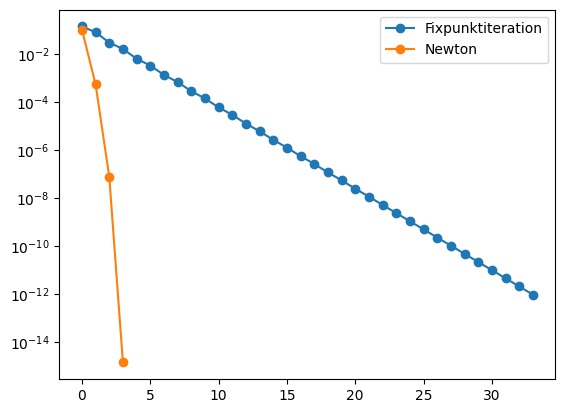

In [25]:
# %% Funktion für Newton
f  = lambda x, y : np.array([np.cos(x)+2*y - 3.1 * x, (x*y**2+np.sin(x)) - 4*y + 1]) 
df = lambda x, y : np.array([[- np.sin(x)  - 3.1, 2] , [(y**2+np.cos(x)), 2*x*y - 4]])

# %% Fixpunktiteration
x0 = np.array([0.5, 0.5])

def fixpunktIteration(F, x, tol = 1e-12):
    d = [2*tol]
    while (np.linalg.norm(d[-1]) > tol):
        y = F(*x)
        d.append(np.linalg.norm(x-F(*x)))
        x = y
    return x, d [1:]

xFp, dFp = fixpunktIteration(F, x0)

# %% Newtoniteration
x0 = np.array([0.5, 0.5])

def newton(f, df, x, tol = 1e-12):
    d = [2*tol]
    while (np.linalg.norm(d[-1]) > tol):
        delta = np.linalg.solve(df(*x), f(*x))
        d.append(np.linalg.norm(delta))
        x -= delta
    return x, d [1:]

xN, dN = newton(f, df, x0)

# %% plot Fehlerverläufe
plt.figure()
plt.semilogy(dFp, 'o-', label = "Fixpunktiteration")
plt.semilogy(dN,  'o-', label = "Newton")
plt.legend()

print("Fixpunkt Fixpunktiteration = ", xFp, " nach ", len(dFp), " Iterationen")
print("Fixpunkt Newtonverfahren   = ", xN, " nach ", len(dN), " Iterationen")